In [74]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [75]:
import os
import pathlib

**EXTRACTION**

In [76]:
def list_files(path, dict_images=None):
    if dict_images is None:
        dict_images = {
            "file_path": [],
            "dir_name": [], 
            "file_name": [],
            "format": [],
            "resolution": [],
            "ratio": [],
            "mode": [],
            "file_size_mb": []
        }
    
    for entry in os.scandir(path): 
        if entry.is_file():

            if not entry.name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            
            actual_dir = pathlib.Path(entry.path).parent.name
            file_name = os.path.splitext(entry.name)[0]
            file_size = os.path.getsize(entry.path)

            try:
                with Image.open(entry.path) as img:
                    img_width, img_height = img.size
                    if img_height == 0:
                        continue

                    img_format, img_mode, img_resolution, img_ratio = img.format, img.mode, img_width*img_height, round(img_width/img_height, 2)

                    dict_images["file_path"].append(entry.path)
                    dict_images["dir_name"].append(actual_dir)
                    dict_images["file_name"].append(file_name)
                    dict_images["format"].append(img_format)
                    dict_images["resolution"].append(img_resolution)
                    dict_images["ratio"].append(img_ratio)
                    dict_images["mode"].append(img_mode)
                    dict_images["file_size_mb"].append(file_size / (1024**2))

            except Exception as e:
                continue

        elif entry.is_dir():
            dict_images =list_files(entry.path, dict_images)

    return dict_images

In [78]:
directory_reid_cat = 'data/reid_cat'
dict_images_reid_cat = list_files(directory_reid_cat)
df_images_reid_cat = pd.DataFrame(dict_images_reid_cat)

**EDA REID CATS**

In [79]:
df_images_reid_cat.head()

,file_path,dir_name,file_name,format,resolution,ratio,mode,file_size_mb
0,data/reid_cat\0001\0001_000.JPG,0001,0001_000,JPEG,7990272,1.33,RGB,0.795949
1,data/reid_cat\0001\0001_001.JPG,0001,0001_001,JPEG,7990272,1.33,RGB,0.730849
2,data/reid_cat\0001\0001_002.JPG,0001,0001_002,JPEG,7990272,1.33,RGB,0.748957
3,data/reid_cat\0001\0001_003.JPG,0001,0001_003,JPEG,7990272,1.33,RGB,0.795803
4,data/reid_cat\0001\0001_004.JPG,0001,0001_004,JPEG,7990272,1.33,RGB,0.753259


In [80]:
df_images_reid_cat_modified = df_images_reid_cat.copy()

In [154]:
df_images_reid_cat_modified.columns[df_images_reid_cat.iloc[0].isna()].tolist()

[]

In [158]:
df_images_reid_cat_modified.info()

<class 'pandas.DataFrame'>
RangeIndex: 13106 entries, 0 to 13105
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   file_path     13106 non-null  str    
 1   dir_name      13106 non-null  int64  
 2   file_name     13106 non-null  str    
 3   format        13106 non-null  str    
 4   resolution    13106 non-null  int64  
 5   ratio         13106 non-null  float64
 6   mode          13106 non-null  str    
 7   file_size_mb  13106 non-null  float64
 8   orientation   13106 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 921.6 KB


In [166]:
html_tabla = df_images_reid_cat_modified.drop(columns=['dir_name']).describe().map(
    lambda x: f'{x:,.2f}'
).to_html()

with open('tablas/tabla_eda.html', 'w') as f:
    f.write(html_tabla)

In [81]:
df_images_reid_cat_modified['format'].value_counts()

format
JPEG    13106
Name: count, dtype: int64

In [82]:
df_images_reid_cat_modified['mode'].value_counts()

mode
RGB    13106
Name: count, dtype: int64

**Analisis columnas**

In [83]:
status_per_cat = df_images_reid_cat.groupby(['dir_name']).agg(
    mean_resolution=('resolution', 'mean'),
    mean_ratio=('ratio', 'mean'),
    mean_file_size=('file_size_mb', 'mean')
)

status_per_cat = status_per_cat.reset_index(drop=True)

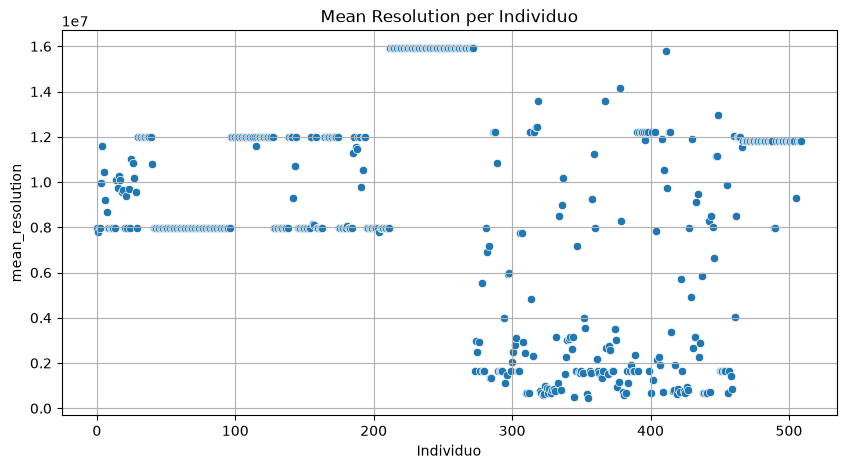

In [170]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=status_per_cat, y='mean_resolution', x=status_per_cat.index)
plt.xlabel('Individuo')
plt.title('Mean Resolution per Individuo')
plt.grid()

plt.savefig('figuras/mean_resolution_per_individual.png', dpi=300, bbox_inches='tight')

plt.show()

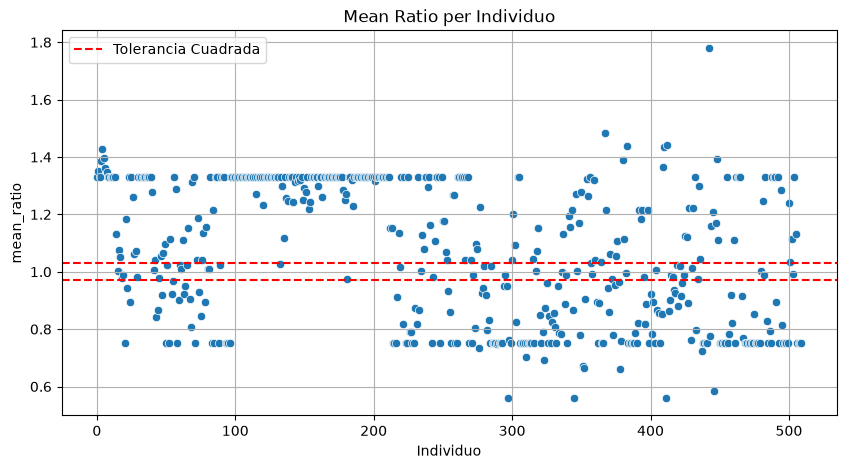

In [171]:
sup_range_square = [1.03 for r in status_per_cat.index]
inf_range_square = [0.97 for r in status_per_cat.index]

plt.figure(figsize=(10, 5))
plt.axhline(y=1.03, color='red', linestyle='--', linewidth=1.5, label='Tolerancia Cuadrada')
plt.axhline(y=0.97, color='red', linestyle='--', linewidth=1.5)
sns.scatterplot(data=status_per_cat, y='mean_ratio', x=status_per_cat.index)
plt.xlabel('Individuo')
plt.title('Mean Ratio per Individuo')
plt.grid()

plt.savefig('figuras/mean_ratio_per_individual.png', dpi=300, bbox_inches='tight')

plt.show()

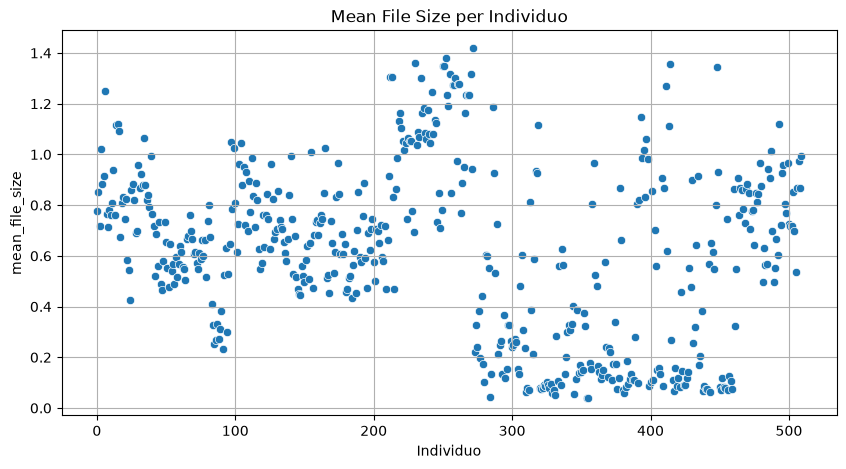

In [172]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=status_per_cat, y='mean_file_size', x=status_per_cat.index)
plt.xlabel('Individuo')
plt.title('Mean File Size per Individuo')
plt.grid()

plt.savefig('figuras/mean_file_size_per_individual.png', dpi=300, bbox_inches='tight')

plt.show()

**manejo de archivos anidados**

In [87]:
df_images_reid_cat_modified['dir_name'] = df_images_reid_cat_modified['dir_name'].apply(lambda x: x.split('_')[0] if '_' in x else x)
df_images_reid_cat_modified['dir_name'] = df_images_reid_cat_modified['dir_name'].apply(lambda x: int(x))

In [88]:
df_images_reid_cat_modified.head()

,file_path,dir_name,file_name,format,resolution,ratio,mode,file_size_mb
0,data/reid_cat\0001\0001_000.JPG,1,0001_000,JPEG,7990272,1.33,RGB,0.795949
1,data/reid_cat\0001\0001_001.JPG,1,0001_001,JPEG,7990272,1.33,RGB,0.730849
2,data/reid_cat\0001\0001_002.JPG,1,0001_002,JPEG,7990272,1.33,RGB,0.748957
3,data/reid_cat\0001\0001_003.JPG,1,0001_003,JPEG,7990272,1.33,RGB,0.795803
4,data/reid_cat\0001\0001_004.JPG,1,0001_004,JPEG,7990272,1.33,RGB,0.753259


In [89]:
print(f"El promedio de fotos por individuo es de: {df_images_reid_cat_modified['dir_name'].value_counts().mean():.0f}")

El promedio de fotos por individuo es de: 26


In [90]:
print(f"La cantidad de individuos presentes es de: {df_images_reid_cat_modified['dir_name'].value_counts().count()}")

La cantidad de individuos presentes es de: 509


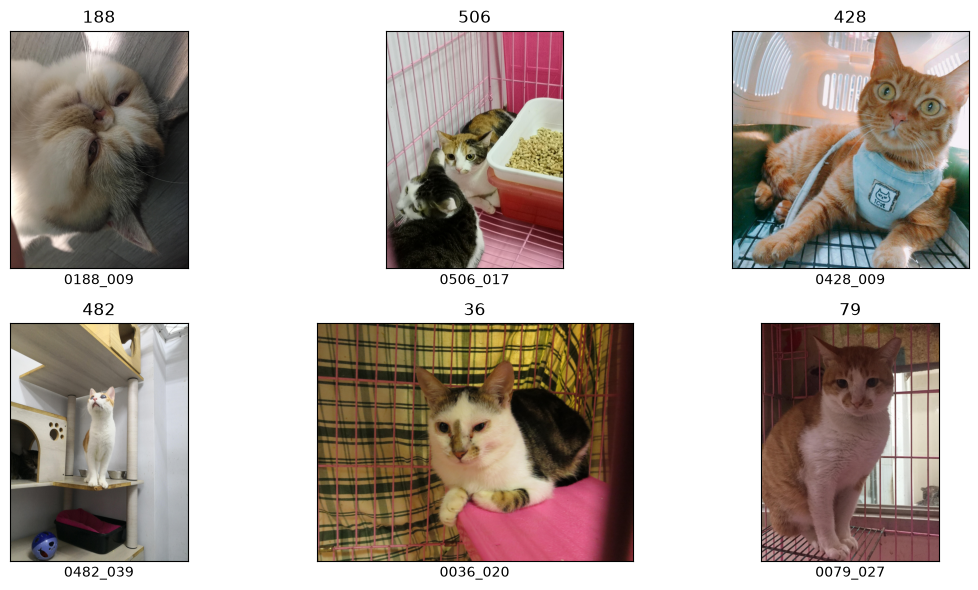

In [173]:
def plot_images(df, seed=None):
    df_sampled = df.sample(n=6, random_state=seed)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()
    for ax, (_, row) in zip(axes, df_sampled.iterrows()):
        title = row['dir_name']
        id_img = row['file_name']

        with Image.open(row['file_path']) as img:
            ax.imshow(img)
            ax.set_title(title)
            ax.set_xlabel(id_img)
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()

    plt.savefig('figuras/img_samples.png', dpi=300, bbox_inches='tight')

    plt.show()
    
plot_images(df_images_reid_cat_modified)

In [92]:
conteo_reid_cat = df_images_reid_cat_modified['dir_name'].value_counts()

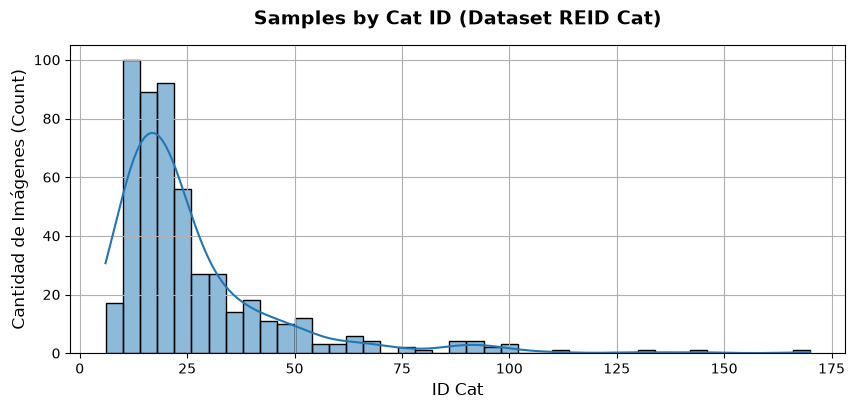

In [174]:
plt.figure(figsize=(10, 4))
plt.title('Samples by Cat ID (Dataset REID Cat)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ID Cat', fontsize=12)
plt.ylabel('Cantidad de Imágenes (Count)', fontsize=12)
sns.histplot(conteo_reid_cat.values,  kde=True)
plt.grid()

plt.savefig('figuras/sample_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

In [175]:
def plot_resolution_vs_file_size(df, class_df=None):
    plt.figure(figsize=(15, 4))
    prefix = f"{class_df} -" if class_df is not None else ""
    plt.subplot(1, 2, 1)
    sns.scatterplot(
        data=df,
        x='resolution', 
        y='file_size_mb',
        hue='format', 
        style='format',
        alpha=0.5
    )
    plt.title(f"{prefix} Resolution vs File Size (MB)")
    plt.grid()

    plt.subplot(1, 2, 2)
    sns.scatterplot(
            data=df,
            x='ratio', 
            y='file_size_mb',
            hue='format', 
            style='format',
            alpha=0.5
    )
    plt.axvline(x=1.03, color='red', linestyle='--', linewidth=1.5, label='Tolerancia Cuadrada')
    plt.axvline(x=0.97, color='red', linestyle='--', linewidth=1.5)
    plt.title(f"{prefix} Ratio vs File Size (MB)")
    plt.grid()

    plt.savefig('figuras/resolution_ratio_vs_file_size.png', dpi=300, bbox_inches='tight')

    plt.show()

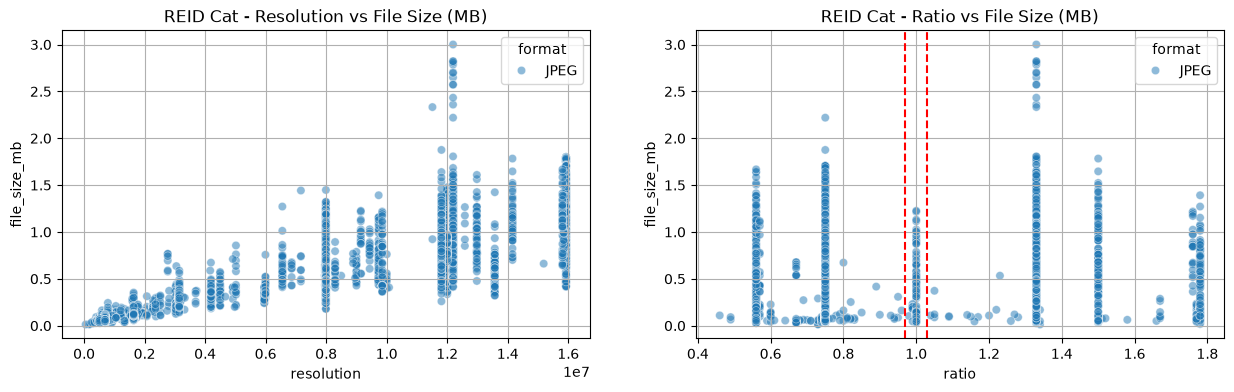

In [176]:
plot_resolution_vs_file_size(df_images_reid_cat_modified, class_df='REID Cat')

In [126]:
status_per_cat.head()

,mean_resolution,mean_ratio,mean_file_size
0,7.990272e+06,1.330000,0.778531
1,7.799110e+06,1.352500,0.852629
2,7.990272e+06,1.330000,0.717292
3,9.972041e+06,1.384643,1.021843
4,1.159935e+07,1.429512,0.885087


In [177]:
def plot_resolution_vs_file_size_grouped(df, class_df=None):
    plt.figure(figsize=(15, 4))
    prefix = f"{class_df} -" if class_df is not None else ""
    plt.subplot(1, 2, 1)
    sns.scatterplot(
        data=df,
        x='mean_resolution', 
        y='mean_file_size',
        alpha=0.5
    )
    plt.title(f"{prefix} Resolution vs File Size (MB)")
    plt.grid()

    plt.subplot(1, 2, 2)
    sns.scatterplot(
            data=df,
            x='mean_ratio', 
            y='mean_file_size',
            alpha=0.5
    )
    plt.title(f"{prefix} Ratio vs File Size (MB)")
    plt.grid()

    plt.savefig('figuras/grouped_resolution_ratio_vs_filesize.png', dpi=300, bbox_inches='tight')

    plt.show()

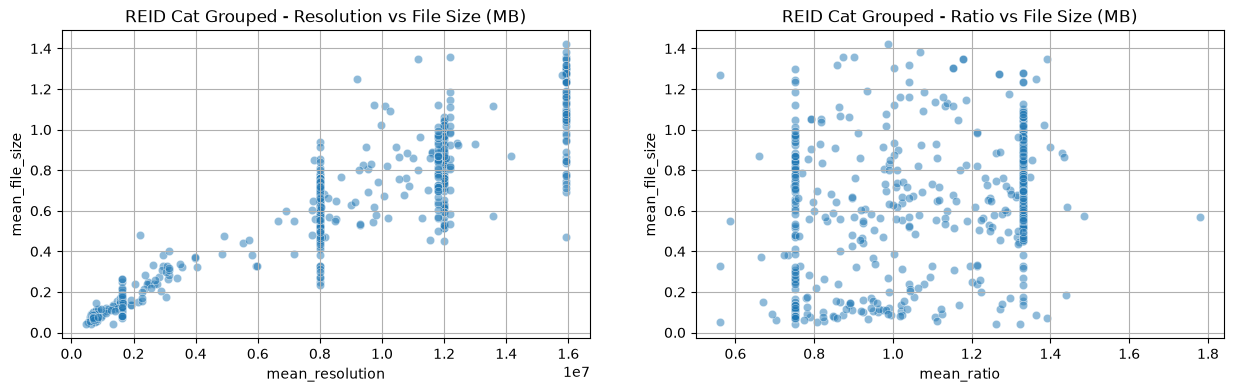

In [178]:
plot_resolution_vs_file_size_grouped(status_per_cat, class_df='REID Cat Grouped')

In [124]:
plt.figure(figsize=(10, 4))
sns.scatterplot()
plt.show()

<Figure size 1000x400 with 0 Axes>

In [179]:
def file_size_vs_format(df, class_df=None):
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 2, 1)
    prefix = f"{class_df} - " if class_df is not None else ""

    sns.boxplot(
        data=df,
        y='file_size_mb',
        x='format',
        hue='format'
    )
    plt.title(f"{prefix}File Size (MB) vs Format")
    plt.grid()

    plt.subplot(1, 2, 2)
    sns.boxplot(
        data=df,
        y='resolution',
        x='format',
        hue='format'
    )
    plt.title(f"{prefix}Resolition vs Format")
    plt.grid()

    plt.savefig('figuras/filesize_resolution_by_format.png', dpi=300, bbox_inches='tight')

    plt.show()

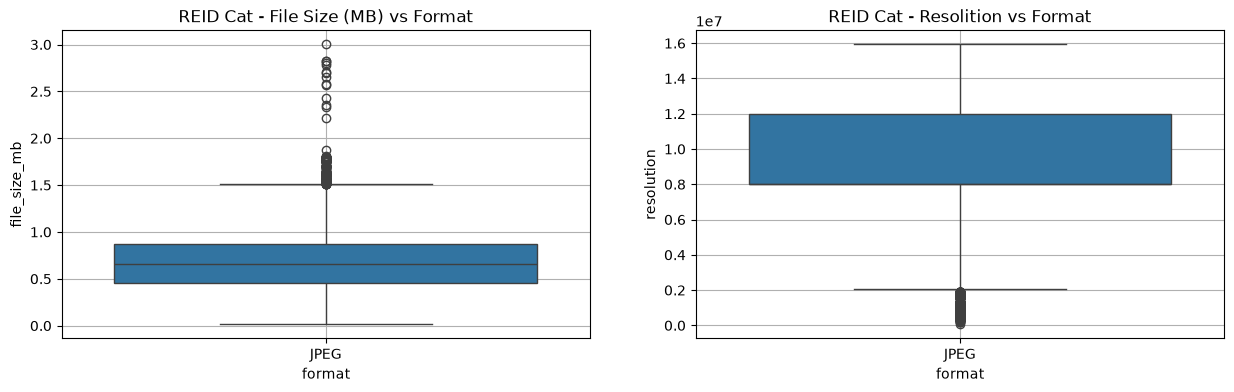

In [180]:
file_size_vs_format(df_images_reid_cat_modified, 'REID Cat')

In [98]:
df_images_reid_cat_modified['orientation'] = df_images_reid_cat_modified['ratio'].apply(
    lambda x: 'square' if 0.97 <= x <= 1.03 else 'vertical' if x < 1 else 'horizontal'
)

In [99]:
conteo_groupby_reid_cat = df_images_reid_cat_modified.groupby(['dir_name', 'orientation'], group_keys=False).size()
conteo_reid_cat_orientation = pd.DataFrame(conteo_groupby_reid_cat)
conteo_reid_cat_orientation = conteo_reid_cat_orientation.reset_index().rename(columns={0: 'conteo'})

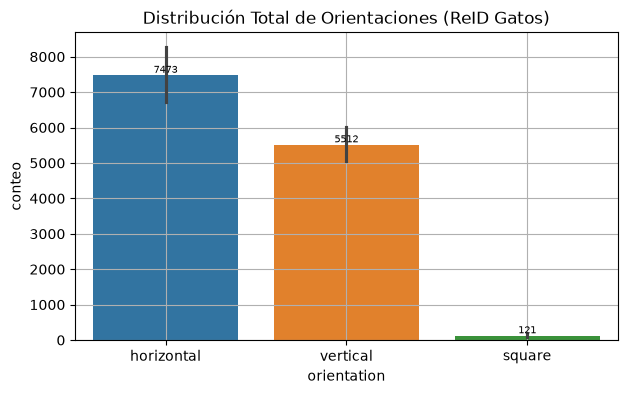

In [181]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=conteo_reid_cat_orientation, 
    y='conteo', 
    x='orientation', 
    estimator='sum', 
    hue='orientation'
)
for container in ax.containers:
    ax.bar_label(container, fontsize=7.5)
    
plt.title('Distribución Total de Orientaciones (ReID Gatos)')
plt.grid()

plt.savefig('figuras/image_orientation_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

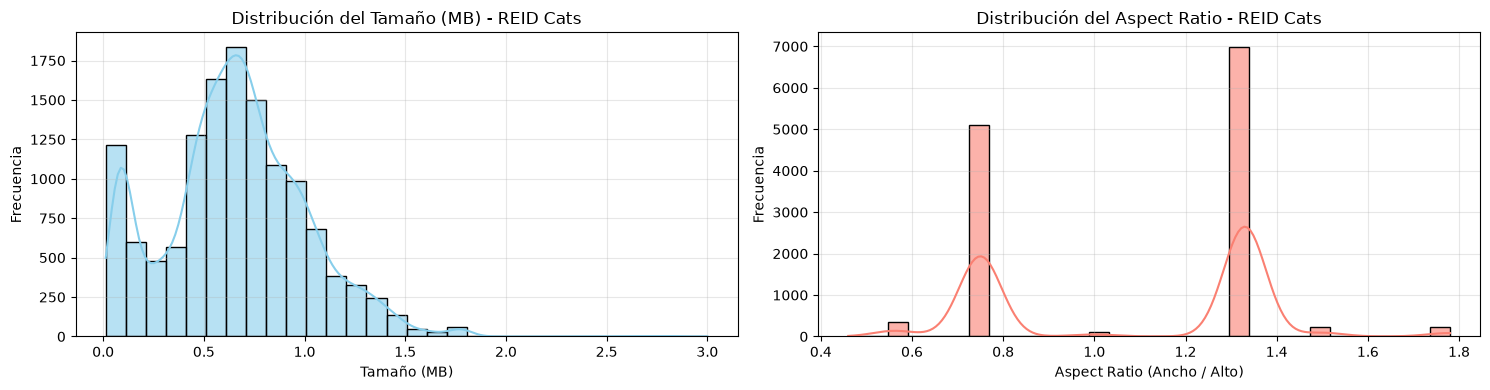

In [182]:
def plot_reid_distributions(df, title_prefix="REID Gatos"):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(
        data=df,
        x='file_size_mb',
        bins=30,
        kde=True,
        color='skyblue',
        alpha=0.6
    )
    plt.title(f'Distribución del Tamaño (MB) - {title_prefix}')
    plt.xlabel('Tamaño (MB)')
    plt.ylabel('Frecuencia')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    sns.histplot(
        data=df,
        x='ratio',
        bins=30,
        kde=True,
        color='salmon',
        alpha=0.6
    )
    plt.title(f'Distribución del Aspect Ratio - {title_prefix}')
    plt.xlabel('Aspect Ratio (Ancho / Alto)')
    plt.ylabel('Frecuencia')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig('figuras/filesize_aspect_ratio_distribution.png', dpi=300, bbox_inches='tight')
    
    plt.show()
plot_reid_distributions(df_images_reid_cat_modified, title_prefix="REID Cats")

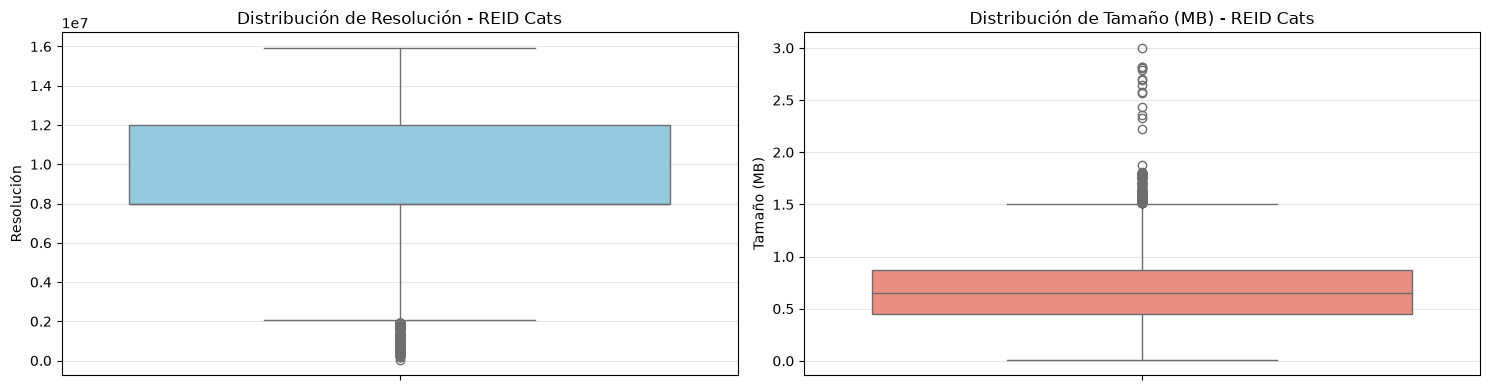

In [183]:
def plot_reid_boxplots(df, title_prefix="REID Gatos"):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    sns.boxplot(
        data=df,
        y='resolution',
        color='skyblue'
    )
    plt.title(f'Distribución de Resolución - {title_prefix}')
    plt.ylabel('Resolución')
    plt.grid(True, axis='y', alpha=0.3)

    plt.subplot(1, 2, 2)
    sns.boxplot(
        data=df,
        y='file_size_mb',
        color='salmon'
    )
    plt.title(f'Distribución de Tamaño (MB) - {title_prefix}')
    plt.ylabel('Tamaño (MB)')
    plt.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()

    plt.savefig('figuras/resolution_filesize_boxplots.png', dpi=300, bbox_inches='tight')
    
    plt.show()

plot_reid_boxplots(df_images_reid_cat_modified, title_prefix="REID Cats")